# Assignment 1: Feature Extraction and Deep Learning for Images
## Section 2: Deep Learning for Image Classification

### Prasanna Paithankar (21CS30065)

4th February 2026

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(42)
np.random.seed(42)

In [2]:
def get_dataloader(batch_size=64, subset_classes=None):
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    )

    trainset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform
    )
    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform
    )

    if subset_classes is not None:
        train_indices = [
            i for i, label in enumerate(trainset.targets) if label in subset_classes
        ]
        trainset = torch.utils.data.Subset(trainset, train_indices)

        test_indices = [
            i for i, label in enumerate(testset.targets) if label in subset_classes
        ]
        testset = torch.utils.data.Subset(testset, test_indices)

    trainloader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2
    )
    testloader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return trainloader, testloader

In [3]:
class CifarCNN(nn.Module):
    def __init__(self, num_classes=3, conv_layers=2, kernel_size=5, use_dropout=False):
        super(CifarCNN, self).__init__()

        self.layers = nn.ModuleList()
        self.use_dropout = use_dropout

        pad = kernel_size // 2
        self.layers.append(nn.Conv2d(3, 6, kernel_size, padding=pad))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.MaxPool2d(2, 2))
        if use_dropout:
            self.layers.append(nn.Dropout(0.25))

        self.layers.append(nn.Conv2d(6, 16, kernel_size, padding=pad))
        self.layers.append(nn.ReLU())
        self.layers.append(nn.MaxPool2d(2, 2))
        if use_dropout:
            self.layers.append(nn.Dropout(0.25))

        current_channels = 16
        for i in range(2, conv_layers):
            next_channels = current_channels * 2
            self.layers.append(
                nn.Conv2d(current_channels, next_channels, kernel_size, padding=pad)
            )
            self.layers.append(nn.ReLU())
            self.layers.append(nn.MaxPool2d(2, 2))
            if use_dropout:
                self.layers.append(nn.Dropout(0.25))
            current_channels = next_channels

        final_dim = 32 // (2**conv_layers)
        self.flatten_size = current_channels * final_dim * final_dim

        self.fc1 = nn.Linear(self.flatten_size, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)

        x = x.view(-1, self.flatten_size)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [4]:
def train_model(model, trainloader, testloader, epochs=10, lr=0.001, optim_name="Adam"):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(model.parameters(), lr=lr)
    if optim_name == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optim_name == "RMSprop":
        optimizer = optim.RMSprop(model.parameters(), lr=lr)
    elif optim_name == "Adamax":
        optimizer = optim.Adamax(model.parameters(), lr=lr)

    train_losses = []
    train_accs = []
    test_accs = []

    print(f"Starting training with {optim_name}, LR={lr}, Epochs={epochs}...")

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for i, data in enumerate(trainloader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(trainloader)
        epoch_acc = 100 * correct / total
        train_losses.append(epoch_loss)
        train_accs.append(epoch_acc)

        model.eval()
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for data in testloader:
                images, labels = data[0].to(device), data[1].to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        test_acc = 100 * correct_test / total_test
        test_accs.append(test_acc)

        print(
            f"Epoch [{epoch + 1}/{epochs}] Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f}% | Test Acc: {test_acc:.2f}%"
        )

    return train_losses, train_accs, test_accs

### (a) Implement a Simple CNN

In [5]:
trainloader, testloader = get_dataloader(batch_size=64, subset_classes=[0, 1, 2])

model_a = CifarCNN(num_classes=3, conv_layers=2, kernel_size=5).to(device)

losses, train_acc, test_acc = train_model(
    model_a, trainloader, testloader, epochs=10, lr=0.001, optim_name="Adam"
)

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6653 | Train Acc: 72.09% | Test Acc: 79.27%
Epoch [2/10] Loss: 0.4691 | Train Acc: 81.45% | Test Acc: 84.00%
Epoch [3/10] Loss: 0.3912 | Train Acc: 84.89% | Test Acc: 82.60%
Epoch [4/10] Loss: 0.3470 | Train Acc: 86.20% | Test Acc: 86.27%
Epoch [5/10] Loss: 0.3119 | Train Acc: 88.09% | Test Acc: 87.40%
Epoch [6/10] Loss: 0.2825 | Train Acc: 89.16% | Test Acc: 87.63%
Epoch [7/10] Loss: 0.2511 | Train Acc: 90.45% | Test Acc: 87.90%
Epoch [8/10] Loss: 0.2305 | Train Acc: 91.20% | Test Acc: 88.43%
Epoch [9/10] Loss: 0.2087 | Train Acc: 92.12% | Test Acc: 86.17%
Epoch [10/10] Loss: 0.1806 | Train Acc: 93.11% | Test Acc: 86.17%


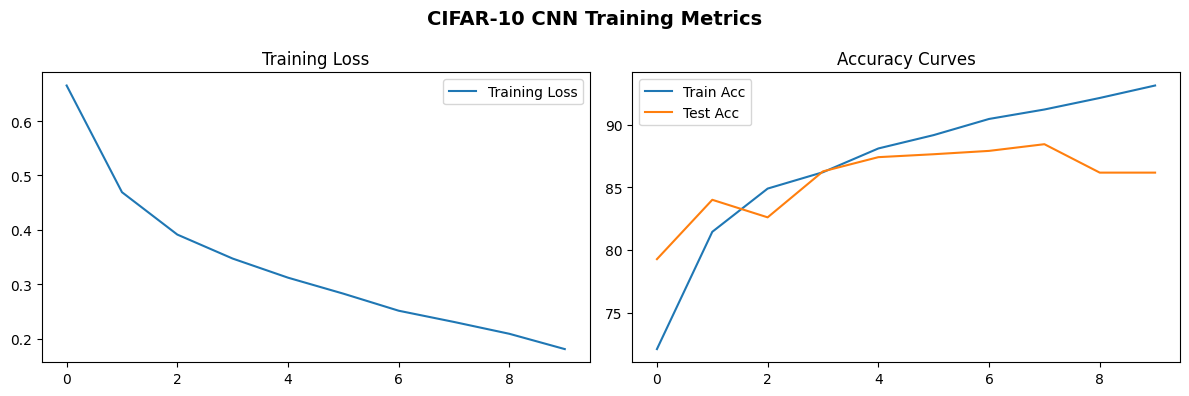

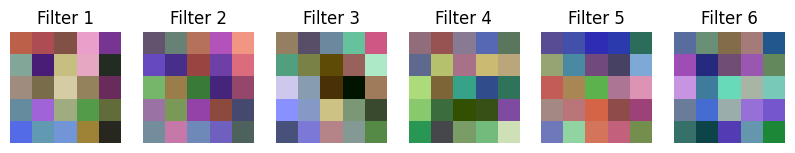

In [6]:
def plot_metrics(losses, train_acc, test_acc, plot_title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if plot_title:
        fig.suptitle(plot_title, fontsize=14, fontweight="bold")

    ax1.plot(losses, label="Training Loss")
    ax1.set_title("Training Loss")
    ax1.legend()

    ax2.plot(train_acc, label="Train Acc")
    ax2.plot(test_acc, label="Test Acc")
    ax2.set_title("Accuracy Curves")
    ax2.legend()

    plt.tight_layout()
    plt.show()


plot_metrics(losses, train_acc, test_acc, plot_title="CIFAR-10 CNN Training Metrics")

first_layer = model_a.layers[0]
filters = first_layer.weight.data.cpu().numpy()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(np.transpose(filters[i], (1, 2, 0)))
    axes[i].axis("off")
    axes[i].set_title(f"Filter {i + 1}")
plt.show()

### (b) Ablations

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 1.6200 | Train Acc: 41.47% | Test Acc: 49.49%
Epoch [2/10] Loss: 1.2779 | Train Acc: 54.02% | Test Acc: 56.66%
Epoch [3/10] Loss: 1.1251 | Train Acc: 60.18% | Test Acc: 59.20%
Epoch [4/10] Loss: 1.0228 | Train Acc: 63.64% | Test Acc: 63.25%
Epoch [5/10] Loss: 0.9461 | Train Acc: 66.63% | Test Acc: 64.26%
Epoch [6/10] Loss: 0.8805 | Train Acc: 68.62% | Test Acc: 63.87%
Epoch [7/10] Loss: 0.8238 | Train Acc: 70.92% | Test Acc: 66.06%
Epoch [8/10] Loss: 0.7750 | Train Acc: 72.75% | Test Acc: 66.23%
Epoch [9/10] Loss: 0.7253 | Train Acc: 74.38% | Test Acc: 67.01%
Epoch [10/10] Loss: 0.6823 | Train Acc: 75.75% | Test Acc: 66.39%


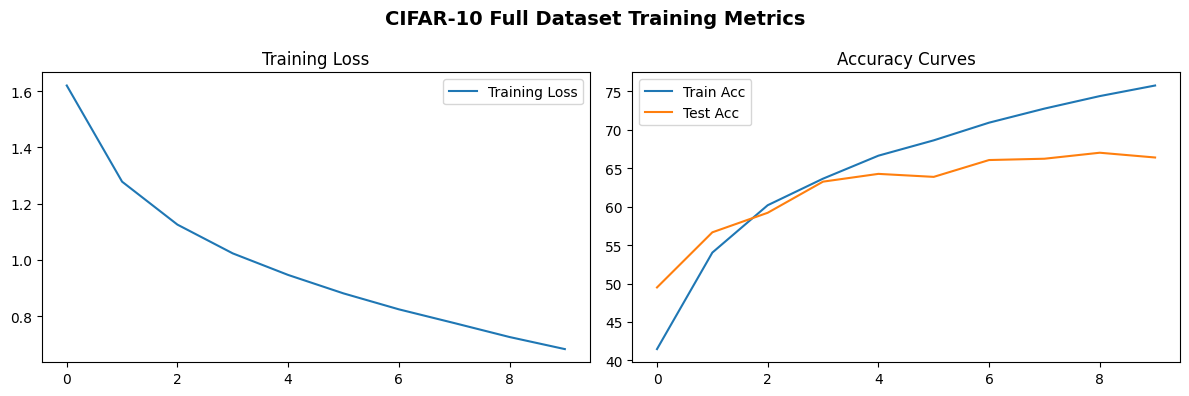

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6700 | Train Acc: 71.69% | Test Acc: 81.63%
Epoch [2/10] Loss: 0.4456 | Train Acc: 82.55% | Test Acc: 82.80%
Epoch [3/10] Loss: 0.3680 | Train Acc: 85.73% | Test Acc: 85.73%
Epoch [4/10] Loss: 0.3327 | Train Acc: 87.54% | Test Acc: 86.33%
Epoch [5/10] Loss: 0.2926 | Train Acc: 88.64% | Test Acc: 86.80%
Epoch [6/10] Loss: 0.2675 | Train Acc: 89.89% | Test Acc: 86.67%
Epoch [7/10] Loss: 0.2433 | Train Acc: 90.69% | Test Acc: 88.73%
Epoch [8/10] Loss: 0.2108 | Train Acc: 92.09% | Test Acc: 88.53%
Epoch [9/10] Loss: 0.1942 | Train Acc: 92.73% | Test Acc: 87.73%
Epoch [10/10] Loss: 0.1645 | Train Acc: 93.94% | Test Acc: 88.50%


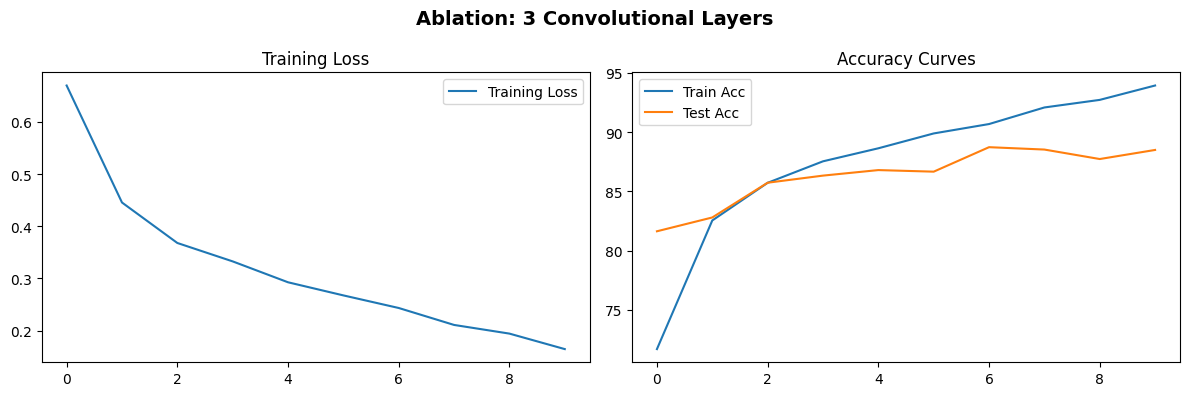

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.7720 | Train Acc: 65.71% | Test Acc: 78.07%
Epoch [2/10] Loss: 0.4919 | Train Acc: 80.71% | Test Acc: 80.53%
Epoch [3/10] Loss: 0.4015 | Train Acc: 84.31% | Test Acc: 84.23%
Epoch [4/10] Loss: 0.3307 | Train Acc: 86.99% | Test Acc: 86.57%
Epoch [5/10] Loss: 0.2804 | Train Acc: 88.91% | Test Acc: 88.03%
Epoch [6/10] Loss: 0.2407 | Train Acc: 90.80% | Test Acc: 89.20%
Epoch [7/10] Loss: 0.2119 | Train Acc: 91.70% | Test Acc: 88.10%
Epoch [8/10] Loss: 0.1777 | Train Acc: 93.07% | Test Acc: 87.87%
Epoch [9/10] Loss: 0.1388 | Train Acc: 94.75% | Test Acc: 87.47%
Epoch [10/10] Loss: 0.1215 | Train Acc: 95.30% | Test Acc: 88.40%


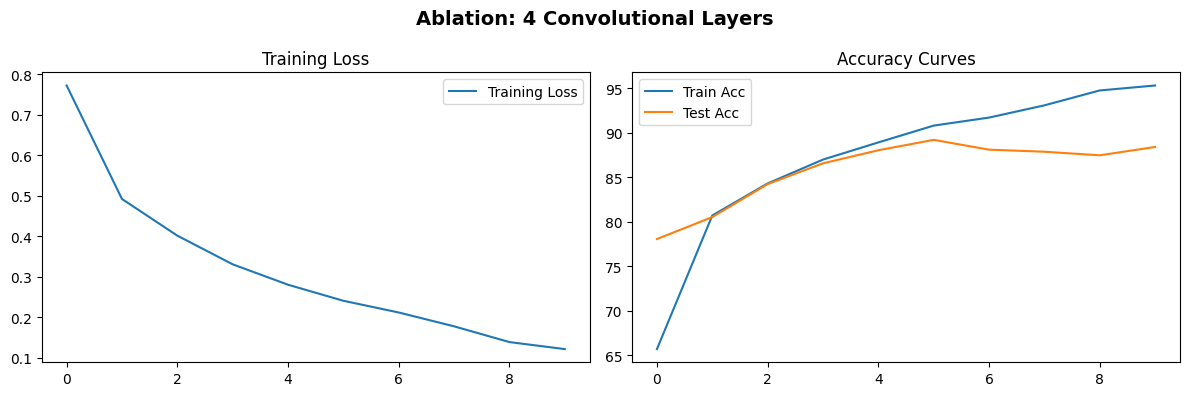

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6624 | Train Acc: 72.04% | Test Acc: 79.93%
Epoch [2/10] Loss: 0.4832 | Train Acc: 80.75% | Test Acc: 78.73%
Epoch [3/10] Loss: 0.4246 | Train Acc: 83.14% | Test Acc: 82.67%
Epoch [4/10] Loss: 0.3792 | Train Acc: 85.54% | Test Acc: 84.40%
Epoch [5/10] Loss: 0.3491 | Train Acc: 86.27% | Test Acc: 83.87%
Epoch [6/10] Loss: 0.3179 | Train Acc: 87.65% | Test Acc: 84.40%
Epoch [7/10] Loss: 0.2909 | Train Acc: 88.85% | Test Acc: 86.73%
Epoch [8/10] Loss: 0.2682 | Train Acc: 89.74% | Test Acc: 86.10%
Epoch [9/10] Loss: 0.2476 | Train Acc: 90.62% | Test Acc: 86.17%
Epoch [10/10] Loss: 0.2198 | Train Acc: 91.63% | Test Acc: 86.47%


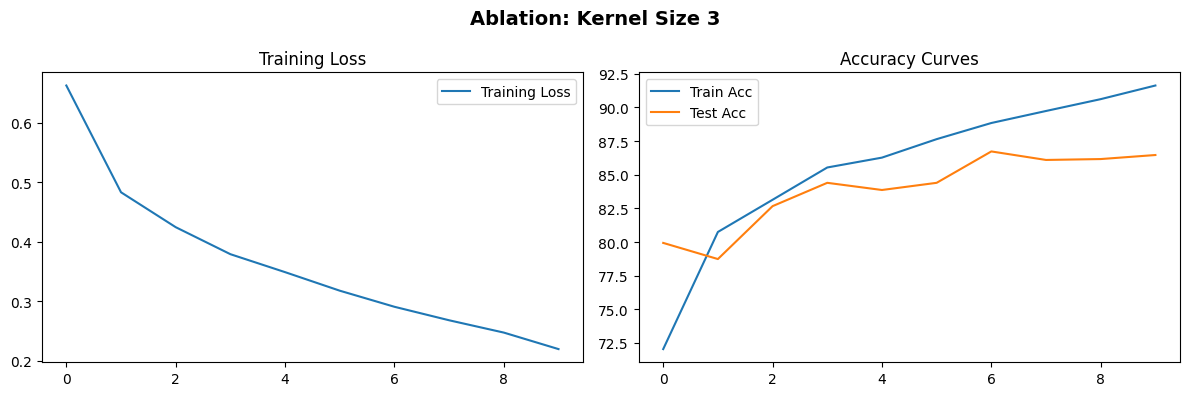

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6644 | Train Acc: 71.83% | Test Acc: 81.97%
Epoch [2/10] Loss: 0.4517 | Train Acc: 82.12% | Test Acc: 84.03%
Epoch [3/10] Loss: 0.3834 | Train Acc: 85.41% | Test Acc: 85.63%
Epoch [4/10] Loss: 0.3348 | Train Acc: 87.34% | Test Acc: 86.10%
Epoch [5/10] Loss: 0.2900 | Train Acc: 89.03% | Test Acc: 87.43%
Epoch [6/10] Loss: 0.2607 | Train Acc: 90.19% | Test Acc: 87.97%
Epoch [7/10] Loss: 0.2282 | Train Acc: 91.27% | Test Acc: 86.47%
Epoch [8/10] Loss: 0.1958 | Train Acc: 92.64% | Test Acc: 87.00%
Epoch [9/10] Loss: 0.1693 | Train Acc: 93.51% | Test Acc: 86.77%
Epoch [10/10] Loss: 0.1308 | Train Acc: 95.11% | Test Acc: 87.73%


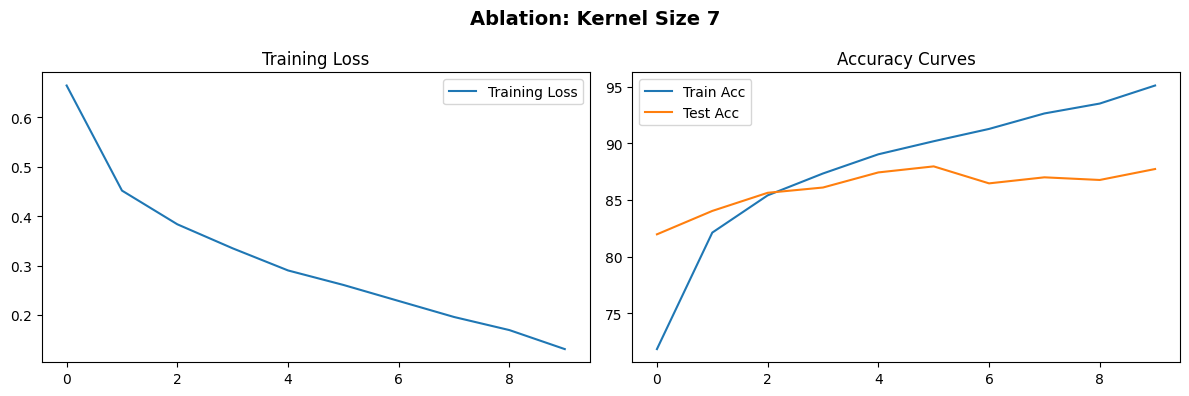

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6786 | Train Acc: 71.56% | Test Acc: 76.70%
Epoch [2/10] Loss: 0.5276 | Train Acc: 78.67% | Test Acc: 81.50%
Epoch [3/10] Loss: 0.4756 | Train Acc: 81.04% | Test Acc: 82.80%
Epoch [4/10] Loss: 0.4391 | Train Acc: 82.69% | Test Acc: 83.60%
Epoch [5/10] Loss: 0.4054 | Train Acc: 84.16% | Test Acc: 85.77%
Epoch [6/10] Loss: 0.3788 | Train Acc: 85.19% | Test Acc: 86.23%
Epoch [7/10] Loss: 0.3649 | Train Acc: 85.75% | Test Acc: 86.97%
Epoch [8/10] Loss: 0.3328 | Train Acc: 86.89% | Test Acc: 87.30%
Epoch [9/10] Loss: 0.3291 | Train Acc: 87.23% | Test Acc: 88.10%
Epoch [10/10] Loss: 0.3056 | Train Acc: 87.96% | Test Acc: 86.73%


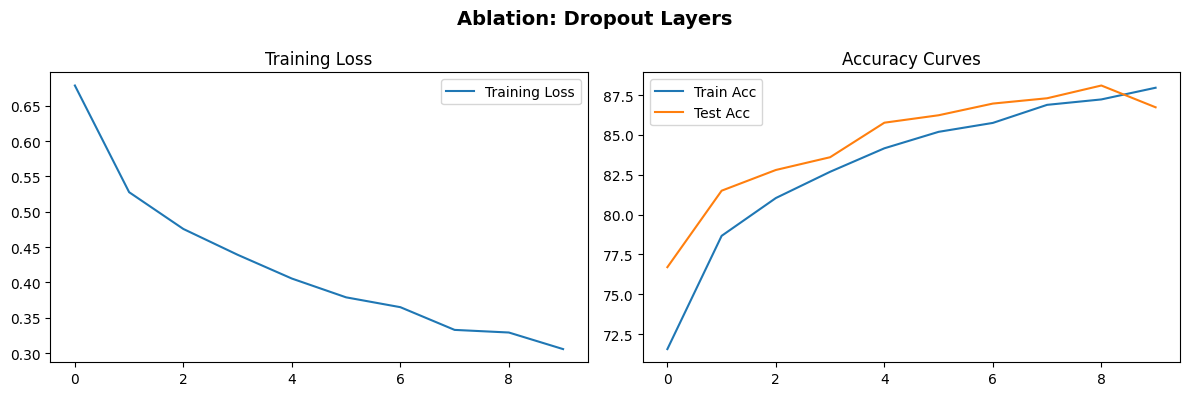

Starting training with SGD, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 1.0974 | Train Acc: 36.39% | Test Acc: 46.73%
Epoch [2/10] Loss: 1.0906 | Train Acc: 48.00% | Test Acc: 49.30%
Epoch [3/10] Loss: 1.0649 | Train Acc: 50.90% | Test Acc: 53.97%
Epoch [4/10] Loss: 0.9501 | Train Acc: 58.19% | Test Acc: 63.40%
Epoch [5/10] Loss: 0.8096 | Train Acc: 66.05% | Test Acc: 70.97%
Epoch [6/10] Loss: 0.6884 | Train Acc: 72.60% | Test Acc: 74.07%
Epoch [7/10] Loss: 0.6026 | Train Acc: 75.79% | Test Acc: 77.00%
Epoch [8/10] Loss: 0.5591 | Train Acc: 77.47% | Test Acc: 78.93%
Epoch [9/10] Loss: 0.5235 | Train Acc: 79.25% | Test Acc: 79.40%
Epoch [10/10] Loss: 0.5055 | Train Acc: 79.86% | Test Acc: 80.93%


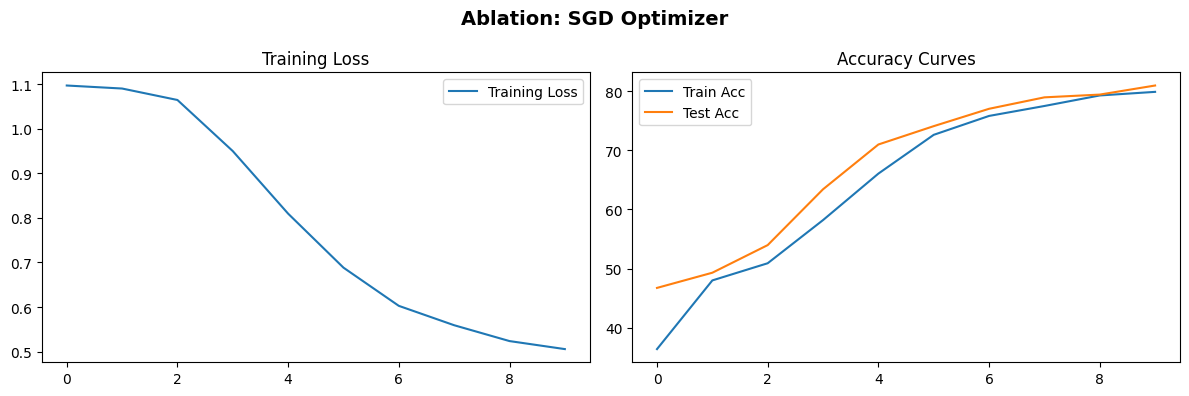

Starting training with RMSprop, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6604 | Train Acc: 71.63% | Test Acc: 78.60%
Epoch [2/10] Loss: 0.4364 | Train Acc: 83.17% | Test Acc: 84.57%
Epoch [3/10] Loss: 0.3822 | Train Acc: 85.05% | Test Acc: 83.13%
Epoch [4/10] Loss: 0.3429 | Train Acc: 86.90% | Test Acc: 86.60%
Epoch [5/10] Loss: 0.3039 | Train Acc: 88.50% | Test Acc: 87.03%
Epoch [6/10] Loss: 0.2755 | Train Acc: 89.52% | Test Acc: 86.80%
Epoch [7/10] Loss: 0.2443 | Train Acc: 90.85% | Test Acc: 80.43%
Epoch [8/10] Loss: 0.2119 | Train Acc: 91.91% | Test Acc: 88.23%
Epoch [9/10] Loss: 0.1827 | Train Acc: 93.09% | Test Acc: 87.07%
Epoch [10/10] Loss: 0.1572 | Train Acc: 94.24% | Test Acc: 86.23%


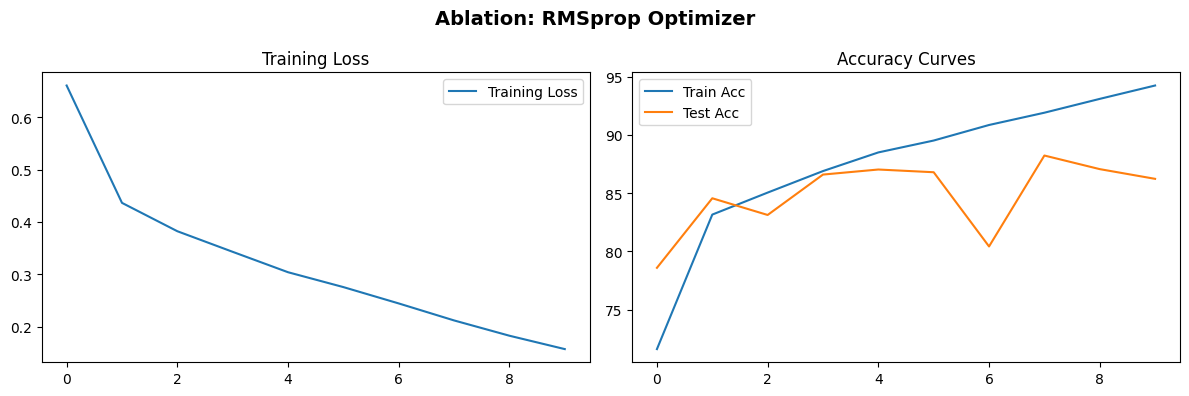

Starting training with Adamax, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.7449 | Train Acc: 67.95% | Test Acc: 76.50%
Epoch [2/10] Loss: 0.5440 | Train Acc: 78.20% | Test Acc: 78.97%
Epoch [3/10] Loss: 0.4943 | Train Acc: 80.35% | Test Acc: 80.93%
Epoch [4/10] Loss: 0.4594 | Train Acc: 81.90% | Test Acc: 82.87%
Epoch [5/10] Loss: 0.4281 | Train Acc: 83.49% | Test Acc: 83.67%
Epoch [6/10] Loss: 0.4060 | Train Acc: 84.18% | Test Acc: 84.30%
Epoch [7/10] Loss: 0.3879 | Train Acc: 84.86% | Test Acc: 83.30%
Epoch [8/10] Loss: 0.3765 | Train Acc: 85.51% | Test Acc: 85.37%
Epoch [9/10] Loss: 0.3522 | Train Acc: 86.45% | Test Acc: 85.53%
Epoch [10/10] Loss: 0.3388 | Train Acc: 86.84% | Test Acc: 85.37%


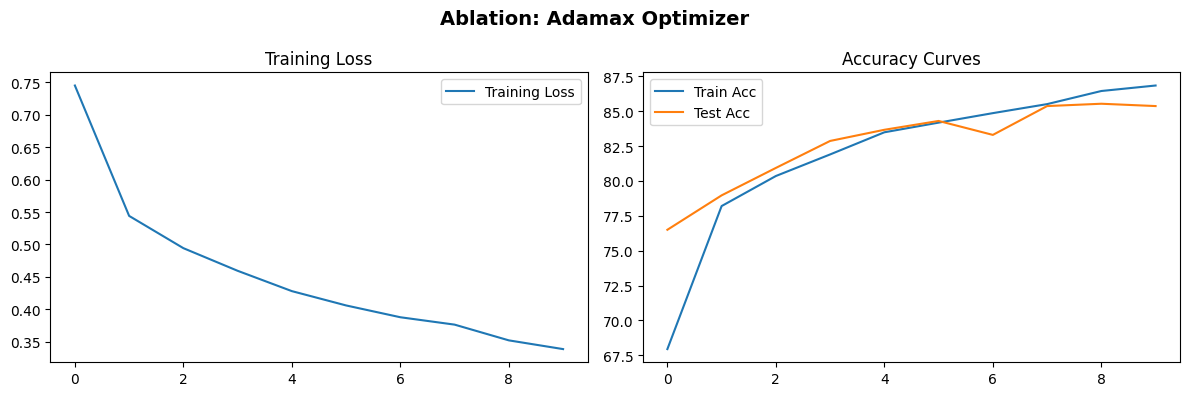

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6643 | Train Acc: 72.13% | Test Acc: 80.00%
Epoch [2/10] Loss: 0.4629 | Train Acc: 81.67% | Test Acc: 82.10%
Epoch [3/10] Loss: 0.3995 | Train Acc: 84.33% | Test Acc: 85.50%
Epoch [4/10] Loss: 0.3549 | Train Acc: 86.38% | Test Acc: 85.93%
Epoch [5/10] Loss: 0.3221 | Train Acc: 87.87% | Test Acc: 86.70%
Epoch [6/10] Loss: 0.2921 | Train Acc: 89.08% | Test Acc: 87.60%
Epoch [7/10] Loss: 0.2658 | Train Acc: 89.87% | Test Acc: 86.50%
Epoch [8/10] Loss: 0.2410 | Train Acc: 90.90% | Test Acc: 87.87%
Epoch [9/10] Loss: 0.2144 | Train Acc: 91.89% | Test Acc: 86.10%
Epoch [10/10] Loss: 0.1872 | Train Acc: 92.99% | Test Acc: 87.50%


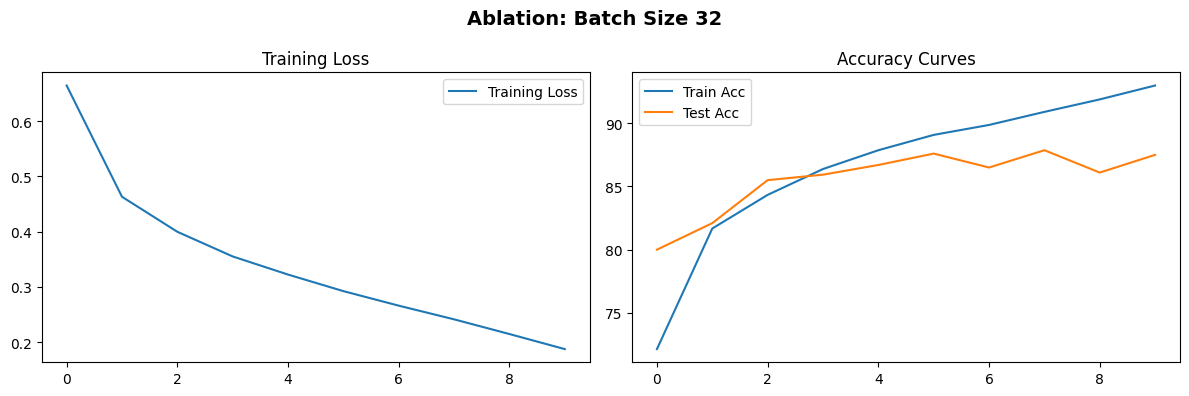

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6462 | Train Acc: 72.97% | Test Acc: 80.40%
Epoch [2/10] Loss: 0.4549 | Train Acc: 81.99% | Test Acc: 84.20%
Epoch [3/10] Loss: 0.3902 | Train Acc: 84.96% | Test Acc: 85.77%
Epoch [4/10] Loss: 0.3514 | Train Acc: 86.51% | Test Acc: 86.63%
Epoch [5/10] Loss: 0.3196 | Train Acc: 87.77% | Test Acc: 87.63%
Epoch [6/10] Loss: 0.2850 | Train Acc: 89.09% | Test Acc: 86.80%
Epoch [7/10] Loss: 0.2568 | Train Acc: 90.29% | Test Acc: 86.93%
Epoch [8/10] Loss: 0.2316 | Train Acc: 91.05% | Test Acc: 86.80%
Epoch [9/10] Loss: 0.2025 | Train Acc: 92.11% | Test Acc: 86.30%
Epoch [10/10] Loss: 0.1752 | Train Acc: 93.36% | Test Acc: 86.70%


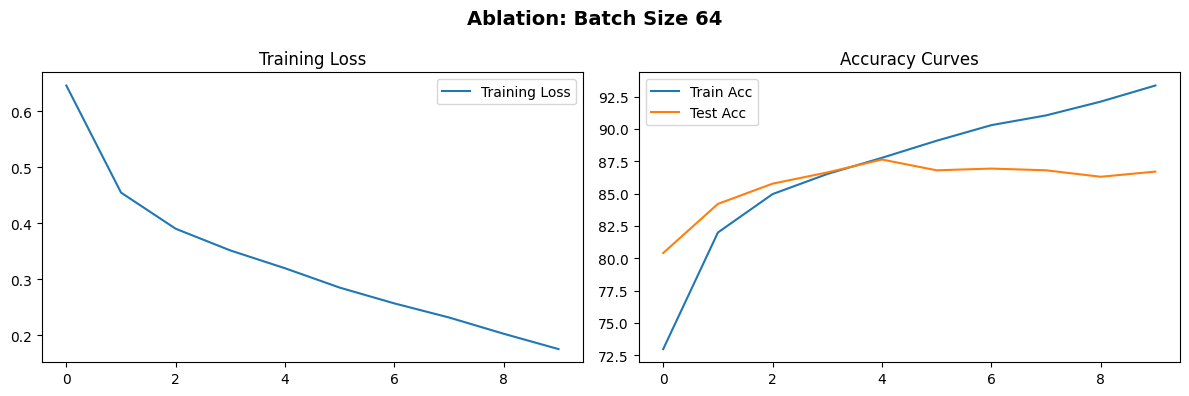

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6596 | Train Acc: 72.52% | Test Acc: 79.90%
Epoch [2/10] Loss: 0.4766 | Train Acc: 81.13% | Test Acc: 83.13%
Epoch [3/10] Loss: 0.4025 | Train Acc: 84.37% | Test Acc: 85.53%
Epoch [4/10] Loss: 0.3652 | Train Acc: 85.83% | Test Acc: 87.03%
Epoch [5/10] Loss: 0.3305 | Train Acc: 87.23% | Test Acc: 86.40%
Epoch [6/10] Loss: 0.3038 | Train Acc: 88.26% | Test Acc: 86.67%
Epoch [7/10] Loss: 0.2737 | Train Acc: 89.63% | Test Acc: 87.87%
Epoch [8/10] Loss: 0.2436 | Train Acc: 90.72% | Test Acc: 85.97%
Epoch [9/10] Loss: 0.2181 | Train Acc: 91.72% | Test Acc: 87.10%
Epoch [10/10] Loss: 0.1992 | Train Acc: 92.44% | Test Acc: 87.53%


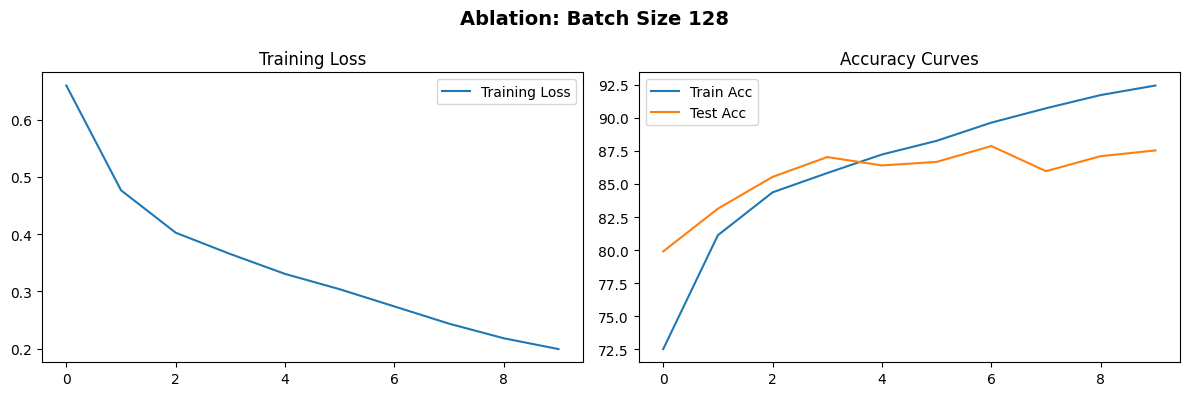

Starting training with Adam, LR=0.01, Epochs=10...
Epoch [1/10] Loss: 0.6539 | Train Acc: 72.87% | Test Acc: 80.60%
Epoch [2/10] Loss: 0.4731 | Train Acc: 81.63% | Test Acc: 83.47%
Epoch [3/10] Loss: 0.4266 | Train Acc: 83.55% | Test Acc: 83.67%
Epoch [4/10] Loss: 0.4084 | Train Acc: 84.31% | Test Acc: 83.87%
Epoch [5/10] Loss: 0.3800 | Train Acc: 85.17% | Test Acc: 84.43%
Epoch [6/10] Loss: 0.3144 | Train Acc: 87.94% | Test Acc: 84.77%
Epoch [7/10] Loss: 0.2985 | Train Acc: 88.62% | Test Acc: 84.80%
Epoch [8/10] Loss: 0.2668 | Train Acc: 89.57% | Test Acc: 82.43%
Epoch [9/10] Loss: 0.2455 | Train Acc: 90.65% | Test Acc: 84.23%
Epoch [10/10] Loss: 0.2384 | Train Acc: 91.28% | Test Acc: 82.67%


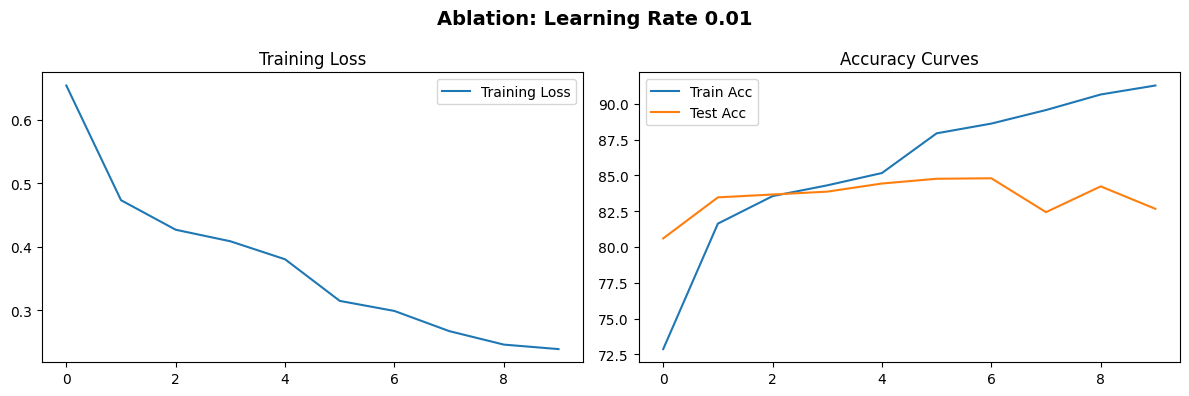

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6278 | Train Acc: 73.70% | Test Acc: 80.17%
Epoch [2/10] Loss: 0.4366 | Train Acc: 82.68% | Test Acc: 83.60%
Epoch [3/10] Loss: 0.3688 | Train Acc: 85.53% | Test Acc: 86.27%
Epoch [4/10] Loss: 0.3292 | Train Acc: 87.13% | Test Acc: 86.83%
Epoch [5/10] Loss: 0.3091 | Train Acc: 88.04% | Test Acc: 87.13%
Epoch [6/10] Loss: 0.2791 | Train Acc: 89.43% | Test Acc: 87.00%
Epoch [7/10] Loss: 0.2533 | Train Acc: 90.37% | Test Acc: 88.17%
Epoch [8/10] Loss: 0.2383 | Train Acc: 90.87% | Test Acc: 87.23%
Epoch [9/10] Loss: 0.2193 | Train Acc: 91.54% | Test Acc: 87.80%
Epoch [10/10] Loss: 0.1938 | Train Acc: 92.62% | Test Acc: 87.43%


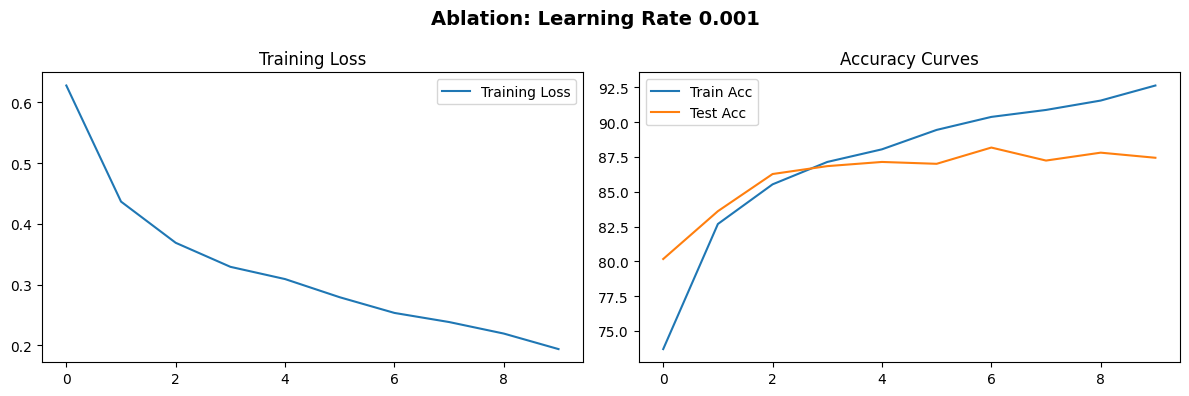

Starting training with Adam, LR=0.0001, Epochs=10...
Epoch [1/10] Loss: 0.9037 | Train Acc: 58.46% | Test Acc: 71.47%
Epoch [2/10] Loss: 0.6567 | Train Acc: 73.79% | Test Acc: 75.90%
Epoch [3/10] Loss: 0.5566 | Train Acc: 77.97% | Test Acc: 77.37%
Epoch [4/10] Loss: 0.5192 | Train Acc: 79.48% | Test Acc: 79.33%
Epoch [5/10] Loss: 0.4988 | Train Acc: 80.52% | Test Acc: 80.73%
Epoch [6/10] Loss: 0.4827 | Train Acc: 81.23% | Test Acc: 80.40%
Epoch [7/10] Loss: 0.4707 | Train Acc: 81.81% | Test Acc: 81.40%
Epoch [8/10] Loss: 0.4648 | Train Acc: 81.75% | Test Acc: 81.33%
Epoch [9/10] Loss: 0.4492 | Train Acc: 82.39% | Test Acc: 81.93%
Epoch [10/10] Loss: 0.4411 | Train Acc: 82.76% | Test Acc: 82.90%


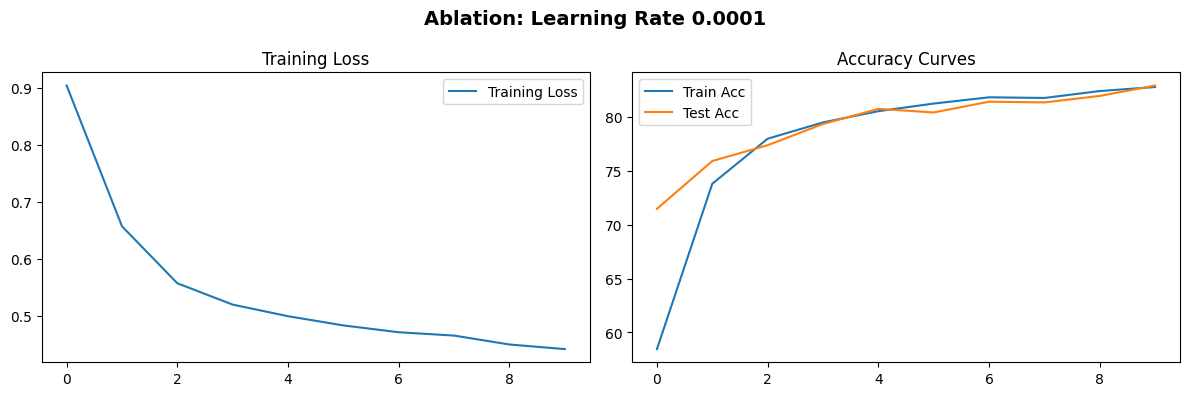

Starting training with Adam, LR=0.001, Epochs=5...
Epoch [1/5] Loss: 0.6635 | Train Acc: 71.19% | Test Acc: 80.87%
Epoch [2/5] Loss: 0.4295 | Train Acc: 82.99% | Test Acc: 85.27%
Epoch [3/5] Loss: 0.3650 | Train Acc: 86.07% | Test Acc: 85.27%
Epoch [4/5] Loss: 0.3186 | Train Acc: 87.57% | Test Acc: 86.73%
Epoch [5/5] Loss: 0.2908 | Train Acc: 88.64% | Test Acc: 86.70%


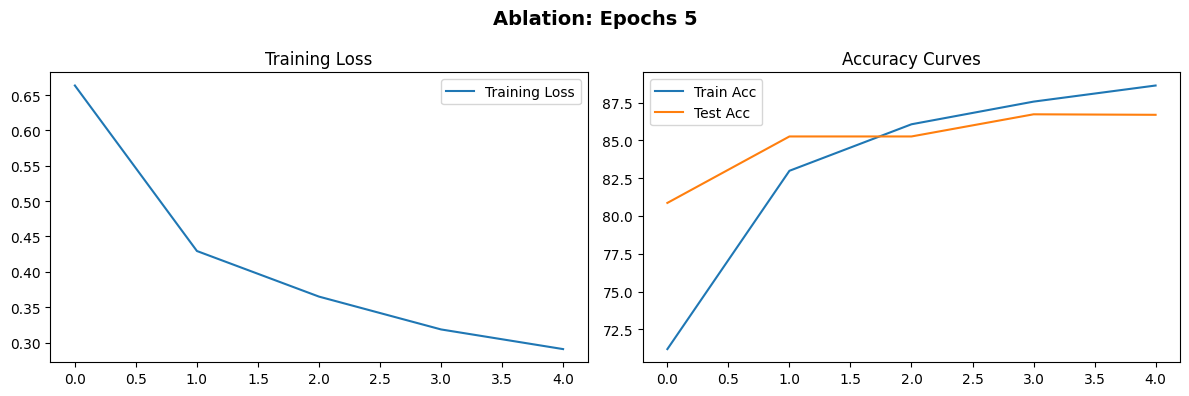

Starting training with Adam, LR=0.001, Epochs=10...
Epoch [1/10] Loss: 0.6514 | Train Acc: 72.47% | Test Acc: 79.93%
Epoch [2/10] Loss: 0.4641 | Train Acc: 81.47% | Test Acc: 83.67%
Epoch [3/10] Loss: 0.4039 | Train Acc: 83.87% | Test Acc: 85.33%
Epoch [4/10] Loss: 0.3679 | Train Acc: 85.41% | Test Acc: 86.23%
Epoch [5/10] Loss: 0.3208 | Train Acc: 87.47% | Test Acc: 87.47%
Epoch [6/10] Loss: 0.2974 | Train Acc: 88.57% | Test Acc: 87.80%
Epoch [7/10] Loss: 0.2737 | Train Acc: 89.55% | Test Acc: 86.53%
Epoch [8/10] Loss: 0.2426 | Train Acc: 90.82% | Test Acc: 88.03%
Epoch [9/10] Loss: 0.2217 | Train Acc: 91.68% | Test Acc: 86.97%
Epoch [10/10] Loss: 0.1990 | Train Acc: 92.49% | Test Acc: 87.53%


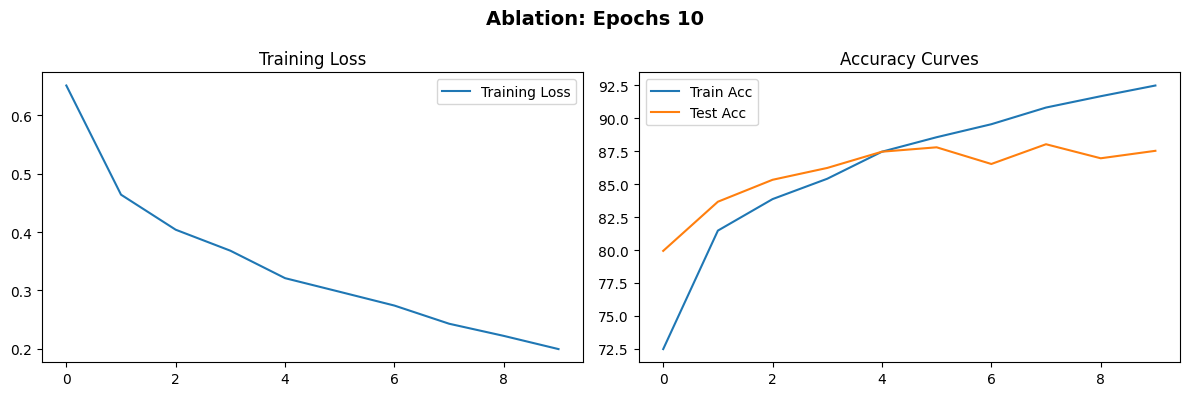

Starting training with Adam, LR=0.001, Epochs=15...
Epoch [1/15] Loss: 0.6724 | Train Acc: 72.03% | Test Acc: 79.33%
Epoch [2/15] Loss: 0.4657 | Train Acc: 81.29% | Test Acc: 84.60%
Epoch [3/15] Loss: 0.3905 | Train Acc: 84.95% | Test Acc: 85.67%
Epoch [4/15] Loss: 0.3384 | Train Acc: 87.08% | Test Acc: 86.23%
Epoch [5/15] Loss: 0.3122 | Train Acc: 88.09% | Test Acc: 85.83%
Epoch [6/15] Loss: 0.2822 | Train Acc: 89.21% | Test Acc: 86.30%
Epoch [7/15] Loss: 0.2511 | Train Acc: 90.41% | Test Acc: 87.20%
Epoch [8/15] Loss: 0.2240 | Train Acc: 91.61% | Test Acc: 87.43%
Epoch [9/15] Loss: 0.1941 | Train Acc: 92.64% | Test Acc: 87.23%
Epoch [10/15] Loss: 0.1728 | Train Acc: 93.70% | Test Acc: 86.83%
Epoch [11/15] Loss: 0.1515 | Train Acc: 94.38% | Test Acc: 87.83%
Epoch [12/15] Loss: 0.1219 | Train Acc: 95.58% | Test Acc: 86.77%
Epoch [13/15] Loss: 0.0973 | Train Acc: 96.50% | Test Acc: 87.33%
Epoch [14/15] Loss: 0.0784 | Train Acc: 97.13% | Test Acc: 86.67%
Epoch [15/15] Loss: 0.0682 | Trai

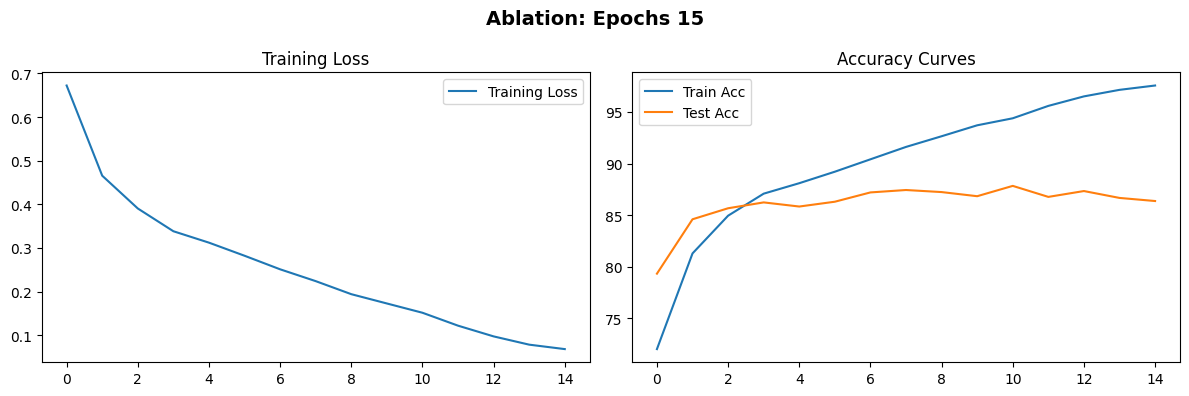

In [ ]:
# Ablation: Train on all classes
full_train, full_test = get_dataloader(batch_size=64, subset_classes=None)
model_full = CifarCNN(num_classes=10).to(device)
full_metrics = train_model(model_full, full_train, full_test, epochs=10)
plot_metrics(*full_metrics, plot_title="CIFAR-10 Full Dataset Training Metrics")

# Ablation: 3 Convolutional Layers
model_layers_3 = CifarCNN(num_classes=3, conv_layers=3, kernel_size=5).to(device)
layer_3_metrics = train_model(model_layers_3, trainloader, testloader, epochs=10)
plot_metrics(*layer_3_metrics, plot_title="Ablation: 3 Convolutional Layers")

# Ablation: 4 Convolutional Layers
model_layers_4 = CifarCNN(num_classes=3, conv_layers=4, kernel_size=5).to(device)
layer_4_metrics = train_model(model_layers_4, trainloader, testloader, epochs=10)
plot_metrics(*layer_4_metrics, plot_title="Ablation: 4 Convolutional Layers")

# Ablation: Kernel Size 3x3
model_kernel_3 = CifarCNN(num_classes=3, conv_layers=2, kernel_size=3).to(device)
kernel_3_metrics = train_model(model_kernel_3, trainloader, testloader, epochs=10)
plot_metrics(*kernel_3_metrics, plot_title="Ablation: Kernel Size 3")

# Ablation: Kernel Size 7x7
model_kernel_7 = CifarCNN(num_classes=3, conv_layers=2, kernel_size=7).to(device)
kernel_7_metrics = train_model(model_kernel_7, trainloader, testloader, epochs=10)
plot_metrics(*kernel_7_metrics, plot_title="Ablation: Kernel Size 7")

# Ablation: Dropout Layers
model_dropout = CifarCNN(
    num_classes=3, conv_layers=2, kernel_size=5, use_dropout=True
).to(device)
dropout_metrics = train_model(model_dropout, trainloader, testloader, epochs=10)
plot_metrics(*dropout_metrics, plot_title="Ablation: Dropout Layers")

# Ablation: SGD Optimizer
model_sgd = CifarCNN(num_classes=3).to(device)
sgd_metrics = train_model(
    model_sgd, trainloader, testloader, optim_name="SGD", lr=0.001
)
plot_metrics(*sgd_metrics, plot_title="Ablation: SGD Optimizer")

# Ablation: RMSprop Optimizer
model_rmsprop = CifarCNN(num_classes=3).to(device)
rmsprop_metrics = train_model(
    model_rmsprop, trainloader, testloader, optim_name="RMSprop", lr=0.001
)
plot_metrics(*rmsprop_metrics, plot_title="Ablation: RMSprop Optimizer")

# Ablation: Adamax Optimizer
model_adamax = CifarCNN(num_classes=3).to(device)
adamax_metrics = train_model(
    model_adamax, trainloader, testloader, optim_name="Adamax", lr=0.001
)
plot_metrics(*adamax_metrics, plot_title="Ablation: Adamax Optimizer")

# Ablation: Batch Size
for batch_size in [32, 64, 128]:
    model_bs = CifarCNN(num_classes=3).to(device)
    bs_metrics = train_model(model_bs, trainloader, testloader, epochs=10)
    plot_metrics(*bs_metrics, plot_title=f"Ablation: Batch Size {batch_size}")

# Ablation: Learning Rate
for lr in [0.01, 0.001, 0.0001]:
    model_lr = CifarCNN(num_classes=3).to(device)
    lr_metrics = train_model(model_lr, trainloader, testloader, epochs=10, lr=lr)
    plot_metrics(*lr_metrics, plot_title=f"Ablation: Learning Rate {lr}")

# Ablation: Number of Epochs
for epochs in [5, 10, 15]:
    model_epochs = CifarCNN(num_classes=3).to(device)
    epochs_metrics = train_model(model_epochs, trainloader, testloader, epochs=epochs)
    plot_metrics(*epochs_metrics, plot_title=f"Ablation: Epochs {epochs}")

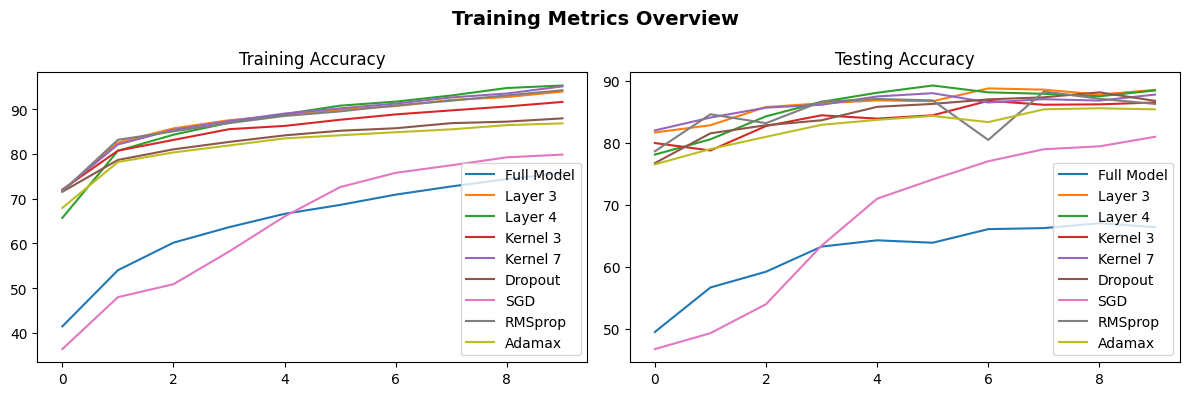

In [ ]:
train_accs, test_accs, labels = (
    [
        full_metrics[1],
        layer_3_metrics[1],
        layer_4_metrics[1],
        kernel_3_metrics[1],
        kernel_7_metrics[1],
        dropout_metrics[1],
        sgd_metrics[1],
        rmsprop_metrics[1],
        adamax_metrics[1],
    ],
    [
        full_metrics[2],
        layer_3_metrics[2],
        layer_4_metrics[2],
        kernel_3_metrics[2],
        kernel_7_metrics[2],
        dropout_metrics[2],
        sgd_metrics[2],
        rmsprop_metrics[2],
        adamax_metrics[2],
    ],
    [
        "Full Model",
        "Layer 3",
        "Layer 4",
        "Kernel 3",
        "Kernel 7",
        "Dropout",
        "SGD",
        "RMSprop",
        "Adamax",
    ],
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Training Metrics Overview", fontsize=14, fontweight="bold")

for train_acc, label in zip(train_accs, labels):
    ax1.plot(train_acc, label=label)
ax1.set_title("Training Accuracy")
ax1.legend()

for test_acc, label in zip(test_accs, labels):
    ax2.plot(test_acc, label=label)
ax2.set_title("Testing Accuracy")
ax2.legend()

plt.tight_layout()
plt.show()

***